# Llama-3.2-1B × opc-sft-stage2 leaderboard — cross-model robustness cell (r=64, 9000 steps)

Cross-model cell from `~/.claude/plans/as-part-of-our-tender-quilt.md`. Same opc-sft-stage2 dataset, same horizon, same optimizer arms as Phase L — but base model swapped to Llama-3.2-1B to address the 'does this work on non-OLMo bases' reviewer objection without a full Phase B/C spend.

Cell: Llama-3.2-1B × opc-sft-stage2 (all 4 sub-configs, Llama-tokenized cache `data/opc_sft_stage2_all_packed_seq2048_llama32`) × global_batch=16 (batch=4 × accum=4) × packed_v1.1 × constant LR × α=r × all-linear × bf16 × compile × single-GPU Blackwell. `max_steps=9000`, `eval_every=250`.

- **AdamW**: η ∈ {3e-5, 1e-4, 3e-4}
- **chord-tight k=1** (`adam-polar-product-lora-coupled-spectral-chord-tight`): η ∈ {3e-3, 1e-2, 3e-2}

Source log groups: `{adamw,chord_tight}_robustness_llama32_1b_opc_r64_blackwell` (2 groups).

**Pass criterion** (per plan): Δ direction matches OLMo (tight-chord < AdamW) at any of the 3 LRs. Magnitude can differ; direction cannot. If direction inverts, the result is OLMo-specific and must be reported as such.

**σ anchor**: borrowed `σ_AdamW(packed_v1, opc-sft-stage2, OLMo, r=64) = 0.0017` as a **proxy only** — cross-model σ is not measured.

In [7]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.loader import load_runs
from lora_playground.plotting import compare_variants_figure
from lora_playground.plotting.colors import OPTIM_COLORS, OPTIM_MARKERS

OPT_ADAMW = 'adamw'
OPT_CT    = 'adam-polar-product-lora-coupled-spectral-chord-tight'

def variant_key(cfg):
    opt = cfg.get('optimizer')
    if opt == OPT_ADAMW: return 'AdamW'
    if opt == OPT_CT:    return 'chord-tight k=1'
    return None

VARIANT_COLORS  = {'AdamW': OPTIM_COLORS.get(OPT_ADAMW, 'black'),
                   'chord-tight k=1': OPTIM_COLORS.get(OPT_CT, 'tab:red')}
VARIANT_MARKERS = {'AdamW': OPTIM_MARKERS.get(OPT_ADAMW, 'o'),
                   'chord-tight k=1': OPTIM_MARKERS.get(OPT_CT, 's')}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## r=64

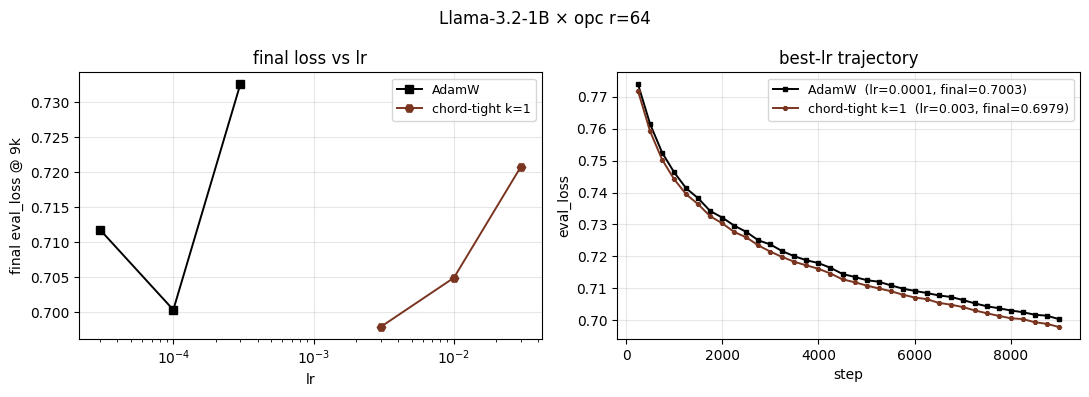

,AdamW,chord-tight k=1
lr,,
0.000030,0.7118,—
0.000100,0.7003,—
0.000300,0.7325,—
0.003000,—,0.6979
0.010000,—,0.7049
0.030000,—,0.7208


,variant,best_lr,final,delta,delta_sigma
0,AdamW,1.0e-04,0.7003,—,—
1,chord-tight k=1,3.0e-03,0.6979,-0.0025,-1.44σ


In [8]:
GROUPS_R64 = [
    'adamw_robustness_llama32_1b_opc_r64_blackwell',
    'chord_tight_robustness_llama32_1b_opc_r64_blackwell',
]
runs = load_runs(where={'log_group': GROUPS_R64}, logs_root='../logs',
                 warn_cross_commit=False, quiet=True)
dedup = {}
for cfg, hist in runs:
    k = (cfg['optimizer'], float(cfg['lr']))
    if k not in dedup or len(hist) > len(dedup[k][1]):
        dedup[k] = (cfg, hist)
fig, table_df, summary_df = compare_variants_figure(
    variants={'AdamW': {'optimizer': OPT_ADAMW},
              'chord-tight k=1': {'optimizer': OPT_CT}},
    common_where={'lora_r': 64}, ref_label='AdamW', sigma_ref=0.0017,
    max_steps=9000, allow_partial=True,
    prefetched_runs=list(dedup.values()), variant_key=variant_key,
    colors=VARIANT_COLORS, markers=VARIANT_MARKERS,
    suptitle='Llama-3.2-1B × opc r=64', figsize=(11, 4),
)
plt.show()
display(table_df.style.format('{:.4f}', na_rep='—'))
display(summary_df.style.format({
    'best_lr': '{:.1e}', 'final': '{:.4f}',
    'delta': '{:+.4f}', 'delta_sigma': '{:+.2f}σ'
}, na_rep='—'))